# 07 — Director outputs (the curated few)

The presentation set, mirroring the y2y trail (`analyses/y2y/21_director_outputs`): only the maps that go on slides, each ONE
asset function in `corridors_director` drawn through `director_plot.wide_map` — the y2y Act 1 **wide layout** (13.33 × 7.5 in
slide: the frame panel at left, zoom insets A and B stacked at right, the key under A, the legend under B; Ethan 2026-09-28,
"formatted exactly like the Act 1 maps from the y2y analysis"). Colours and words for the corridor classes and the cost
swatches come from `corridors_mapstyle` (the §3a tokens); layout, typography and basemap from `director_plot` (one codebase
with 21, so the two packages cannot drift). The record (every figure, star plot, table, GIS export) stays in
`06_tables_and_figures.ipynb`.

**Insets.** `INSETS = "clusters"` sizes A and B on the package's numbered clusters (`director_package/tables/picks.csv` +
`geotiffs/clusters.gpkg` in the y2y schema — the NEXT step). Until those exist, `"interim"` uses the record's frames A (options
1–2, Nahanni's ways south) and B (option 3, Gwillim Lake ↔ Pine Le Moray — numbered 5 before 2026-09-28). Both insets
share one map scale. One switch; nothing else changes.

Outputs → `analyses/northern_connectivity/director_package/director_outputs/` (PNG at 300 dpi; the PDF twin was retired 2026-10-01) — the y2y / Alberta folder structure since 2026-10-01 (`cd.PKG_DIR`; `summary.json` names the run). Zero solves.


In [7]:
# ---- Setup: find the project root, import the shared engines -----------------
import sys, pathlib
_cands = [p for p in [pathlib.Path.cwd(), *pathlib.Path.cwd().parents] if (p / "config.py").exists()]
assert _cands, f"config.py not found above {pathlib.Path.cwd()} -- run this notebook from inside the repo"
ROOT = _cands[0]
sys.path.insert(0, str(ROOT))

import importlib
import matplotlib.pyplot as plt
import config
import corridors_core as cc
import corridors_mapstyle as ms          # the §3a tokens: class + cost colours and words
import corridors_director as cd
import director_plot as dp               # the y2y Act 1 wide layout (one codebase with analyses/y2y/21)
for _m in (config, cc, ms, cd, dp):
    importlib.reload(_m)

RUN = "v2_run003"                        # <-- the run to present
INSETS = "interim"                       # "interim" = frames A (options 1-2) + B (option 5) | "clusters" = the package's numbered clusters (next step)
R = cc.load_results(config.RESULTS_DIR / "corridors_north" / RUN)
P = cd.package(R, n_examples=7)
F = cd.director_frame(P)                 # the run as a director_plot frame: 300 m grid, PA nodes grey, IPCAs as the overlay, the §3a sector window
cd.propose_examples(P)                   # the rule-based proposal (spec 06 §2) + the pin checks -- re-sign EXAMPLE_PICKS from it when the pin rule fires
dp.STYLE.update(cd.WIDE_STYLE)           # the northern knobs for the wide layout -- tweak dp.STYLE HERE, after this line, before drawing
plt.rcParams.update(dp.SPEC_RC)
OUT = P.out / "director_outputs"; OUT.mkdir(exist_ok=True)
print(f"frame {F.G.shape} @ {1000 / F.PX_PER_KM:.0f} m · window px {tuple(round(v) for v in F.WINDOW)} · "
      f"clusters {'attached' if F.PICKS is not None else 'not yet (interim insets)'} → {OUT}")


v2_run003: results context loaded (60 edges, 28 branches, corridor 31,103 km²)
director package: classes -> both 1 · edge 6 · squeezed 7 · securing 31 | 6 examples | H8 closed
package -> analyses/northern_connectivity/director_package  (run v2_run003)
proposed example slots (spec 06 §2 v1.2.18 -- class-and-width-first; top class = D23 land-aware top class (classify_links); sign into EXAMPLE_PICKS):
slot  edge_id                                           pair                                          cls link_geometry  width_new_km  squeeze_ratio_obs  width_ratio_p10  n_pairs_lost  n_branches   alt_kind  road_crossing
  S1 E021_039                   Gwillim Lake ↔ Pine Le Moray                                         both         strip        13.868           0.404456         0.115570           135         1.0       hard           True
  S2 E007_045          Wilps Gwininitxw ↔ Swan Lake Kispiox… edge (filled: fewer than 3 in the top class)         strip        14.613           0.951739  

## 01 — the movement-cost surface

What the land is made of: the four movement-cost classes (1 intact · 10 roads and cuts · 100 converted · 1000 water, ice,
settlement; the O'Brien et al. transboundary extension of Pither et al. 2023) in the M0b magma swatches, existing PAs grey,
the draft IPCAs filled + outlined, postal codes on the frame, names + towns in the insets. The class shares print below for
the slide caption. No corridors on this map (spec 06 v1.2.16).


movement cost, share of the routable area: 1: 88.2% · 10: 5.4% · 100: 0.3% · 1000: 6.1%


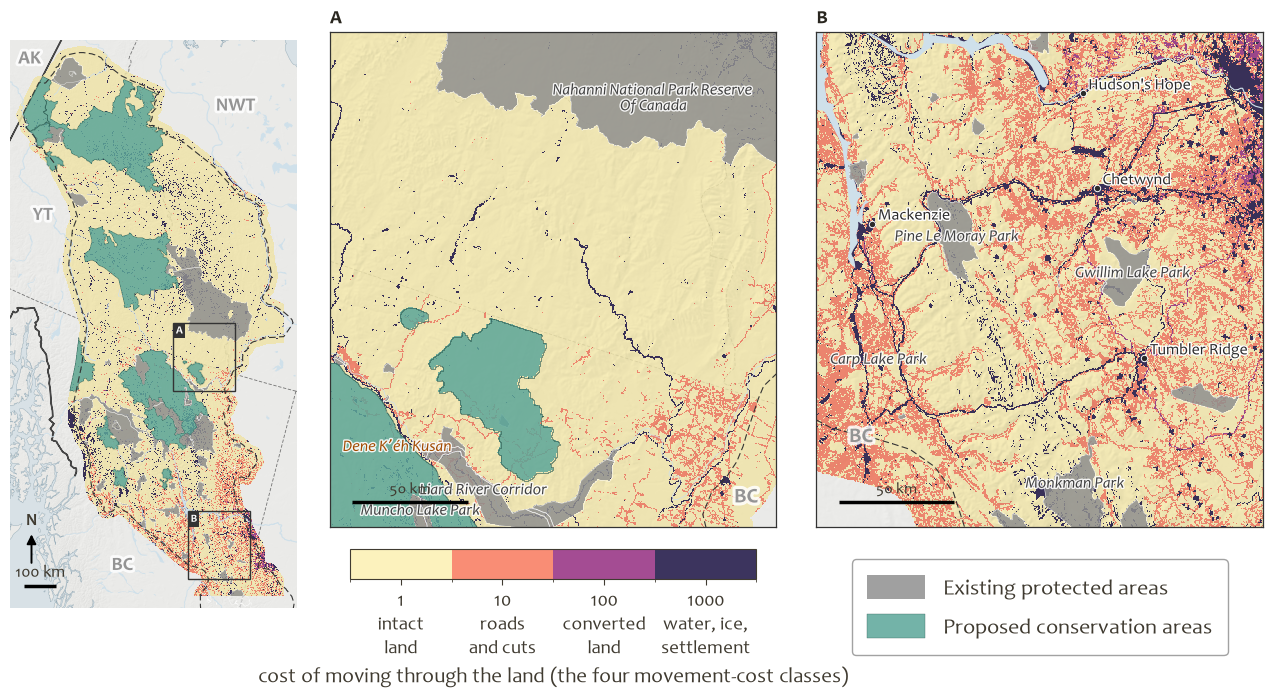

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/northern_connectivity/director_package/director_outputs/01_movement_cost.png')

In [8]:
cd.figure_cost_wide(P, OUT / "01_movement_cost.png", insets=INSETS)


## 02 — where the land still offers choices

The corridor network by routing class = **corridor pressure** (Minimum (options) · Some (narrowing) · A lot (last
affordable) · Maximum (only viable connection); the §3a palette and words), the key in the ramp slot under inset A; the same
frame, insets and legend as 01. While H8 is open the squeezed class is folded into securing, exactly as on the record's M1.


links per class: securing 31 · squeezed 7 · edge 6 · both 1


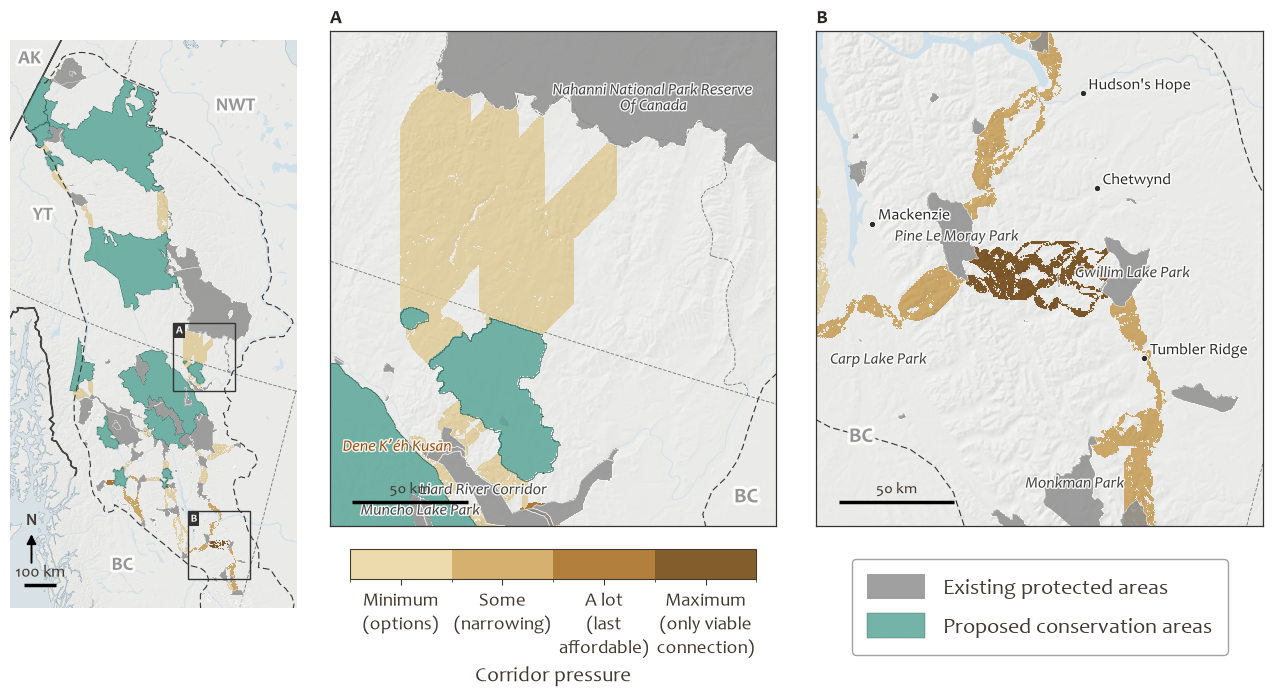

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/northern_connectivity/director_package/director_outputs/02_where_choices.png')

In [9]:
cd.figure_choices_wide(P, OUT / "02_where_choices.png", insets=INSETS)


## 03 — the route options (1–4)

The deck's numbered examples: **1–2** = Nahanni's two ways south (to Dene Kʼéh Kusān, to the Liard River Corridor; inset A),
**3** = Gwillim Lake ↔ Pine Le Moray (the only viable connection; inset B), **4** = Gwillim Lake ↔ Monkman, a narrowing
corridor inside inset B (the pick is one line in `EXAMPLE_PICKS`; Carp Lake ↔ Pine Le Moray, at 0.23× its natural width, is
the alternative). Each option = one link's full corridor band (as on the record's M2), filled in its number's colour from the
y2y cluster palette over the pressure classes, numbered at the band's median cell; the PA / IPCA fills sit on top, as on M2.
The legend entry is the y2y cluster swatch, reading "Route options". Renumbering runs through 06 (M2 shows 1, 2, 5, 6; M3
marks 3, 4, 7; stars and tables follow).


route options: 1 #D7263D at px (1934, 3176) (e) · 2 #1E90FF at px (1804, 3158) (ne) · 3 #E040A0 at px (2112, 5230) (nw) · 4 #FF7F00 at px (2260, 5430) (ne)


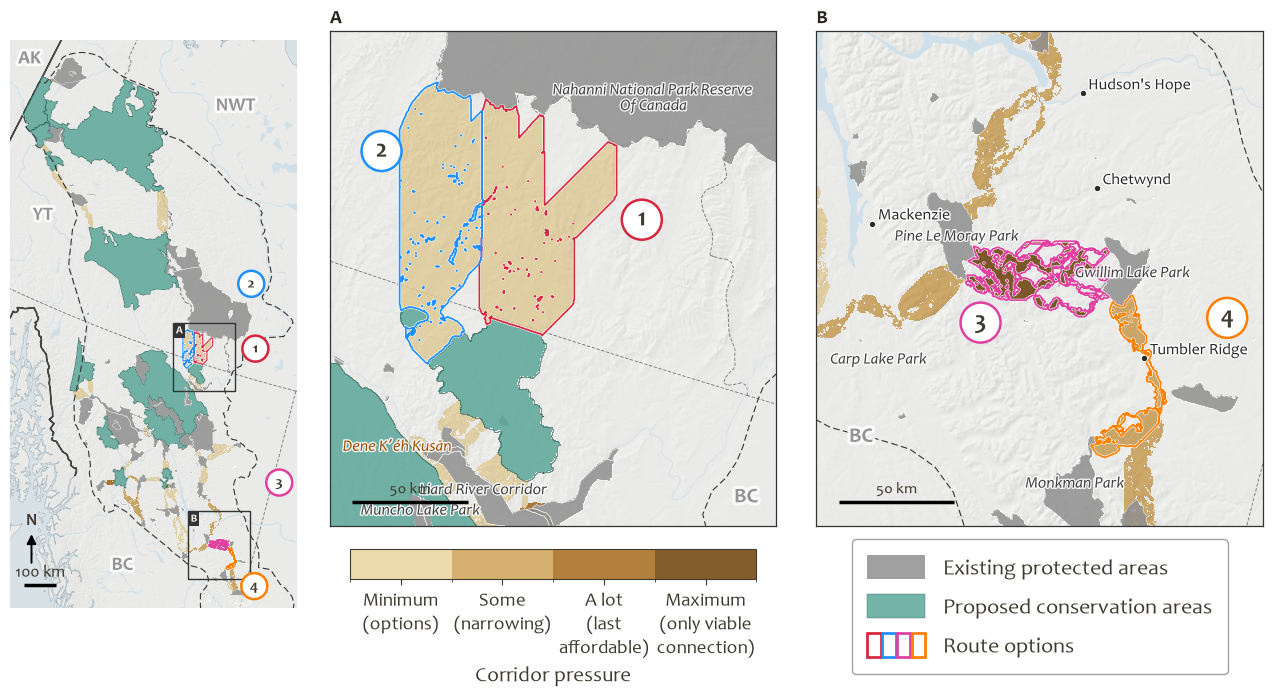

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/northern_connectivity/director_package/director_outputs/03_route_options.png')

In [10]:
cd.figure_options_wide(P, OUT / "03_route_options.png", insets=INSETS)


## 04 — the route options: star plots + locators

The y2y Act 1 stars (`director_plot.star_grid`, one star per option in its colour): each axis = the option's mean PERCENTILE
of a theme against the Y2Y-wide allocatable landscape (`director_core.block_percentiles`; dashed ring 0.5 = the typical
unprotected cell; fractional 300 m → 1 km cover, M6.5) — the same construction as the record's `star_options` and the y2y
cluster stars. Under them, the two inset windows A (options 1–2) and B (3–4) as locator panels on the star grid's geometry:
two panels for four stars, square, one scale, the classes + options as on 03. The first call computes the y2y layers'
percentiles (~1–2 min) and caches them on `P`.


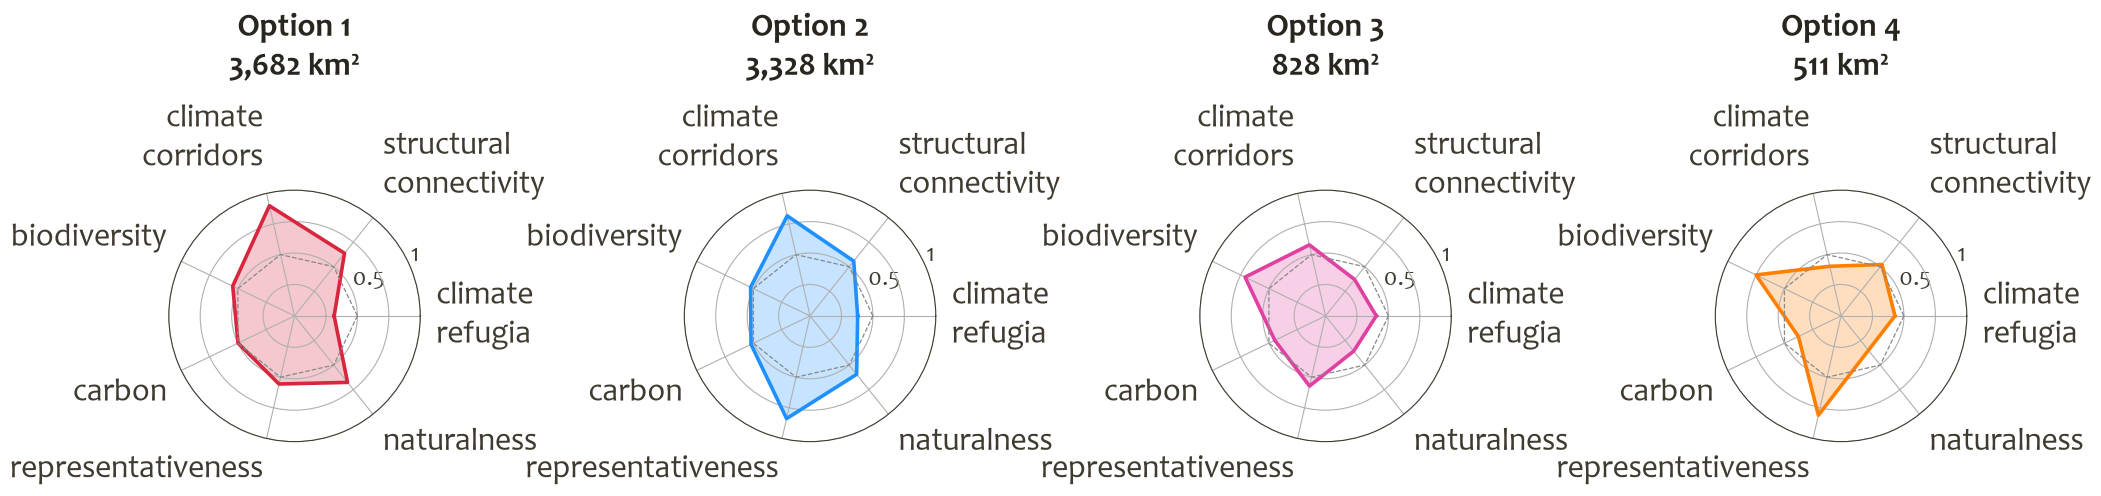

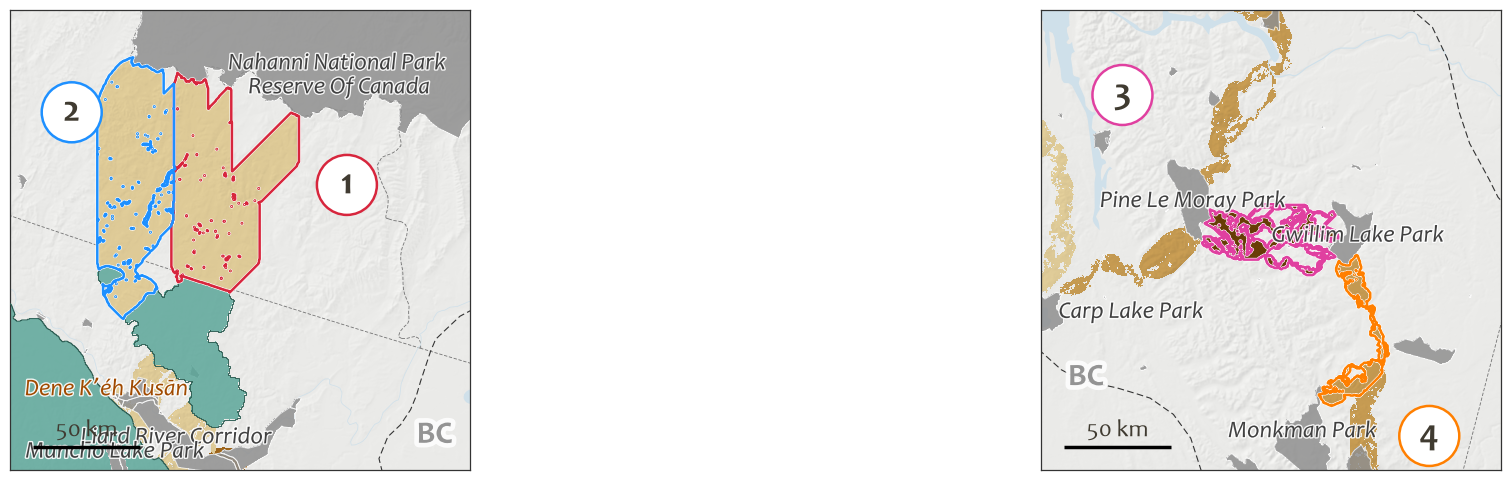

PosixPath('/Users/ethanberman/Dropbox/Python Projects/y2y-spatial-optimization/analyses/northern_connectivity/director_package/director_outputs/04b_route_option_locators.png')

In [11]:
cd.option_stars(P, OUT / "04_route_option_stars.png")
cd.option_locators(P, OUT / "04b_route_option_locators.png", insets=INSETS, panel_px=620)   # + each panel as its own file (_A, _B)


## 05 — the route options: consequences

The y2y consequences table (`director_plot.consequences_table`, transposed, per-row red → blue fills over the option
columns): mean raw value in the option's land ÷ mean over Y2Y-wide allocatable land, per theme ("2.3×" = 2.3 times the
average unprotected cell), columns = options 1–4 then two reference nodes — Nahanni National Park Reserve and Dene Kʼéh
Kusān (`cd.CONSEQ_REFERENCE_NODES`; the y2y rule: real example areas, one PA + one IPCA). Rows also to
`director_package/tables/route_option_consequences.csv`.


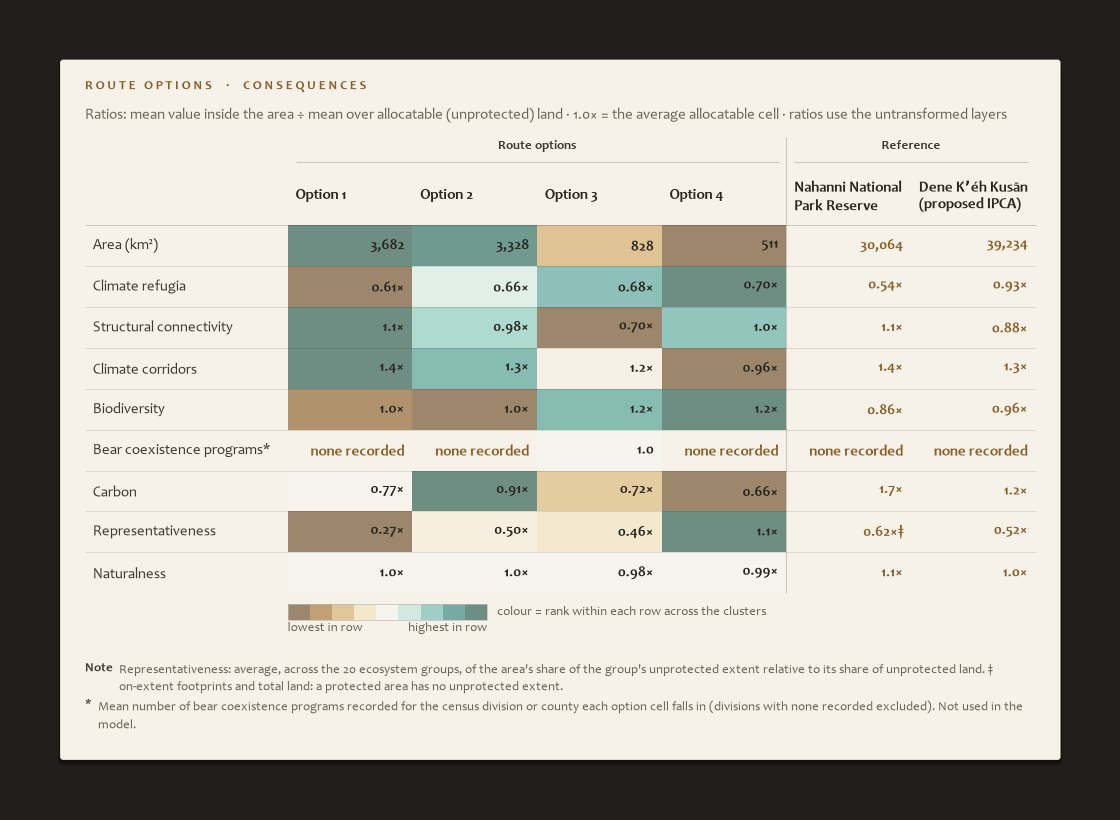

,kind,number,name,area_km2,pct_protected,pct_core habitat,pct_structural connectivity,pct_climate corridors,pct_biodiversity,pct_carbon,...,rq_extent_T6.4.web.orig_v1.0,rq_extent_TF1.2.web.orig_v2.0,rq_extent_TF1.6_TF1.7.web.merged_v3,bear_programs_mean,bear_units_overlapped,bear_groups_n,bear_recorded_pct,bear_suspect_units,bear_by_division,bear_by_division_named
0,option,1,Dene Kʼéh Kusān [part… ↔ Nahanni [part 1],3681.90,0.085554,0.315053,0.637511,0.898515,0.545702,0.498699,...,1.565931,0.0,0.000000,NaN,3,0,0.000000,,,
1,option,2,Dene Kʼéh Kusān [part… ↔ Nahanni [part 1] → De...,3328.47,0.090432,0.378794,0.557293,0.816359,0.524835,0.521054,...,1.565931,0.0,0.000000,NaN,3,0,0.000000,,,
2,option,3,Gwillim Lake ↔ Pine Le Moray,827.91,0.564071,0.403344,0.370591,0.579245,0.710421,0.447932,...,1.565931,0.0,0.000000,1.0,2,1,2.317885,,1 (2%),Fraser-Fort George_British Columbia [fid 19]: ...
3,option,4,Gwillim Lake ↔ Monkman,510.84,0.385639,0.428691,0.522590,0.404821,0.750883,0.376776,...,1.487707,0.0,0.000000,NaN,1,0,0.000000,,,
4,reference,,Nahanni National Park Reserve,30063.87,99.621885,0.236652,0.580679,0.812449,0.363928,0.645915,...,0.165397,0.0,2.811083,NaN,3,0,0.000000,,,
5,reference,,Dene Kʼéh Kusān,39234.06,0.722695,0.607513,0.463628,0.699714,0.484700,0.591726,...,1.565931,0.0,0.000000,NaN,4,0,0.000000,,,


In [12]:
cd.option_consequences(P, OUT / "05_route_option_consequences.png")
